# PVGIS ST-GNN + SDE-Net: previsione diretta multi-orizzonte t+1…t+6

Un **solo training** produce sei canali di output, uno per ogni ora futura da t+1 a t+6. Non vengono addestrati sei modelli separati e non viene usato rollout autoregressivo. La loss è la media della Gaussian NLL sui target `[B, N, 6]`.

La post-hoc usa esclusivamente `anomaly_group`, ottenuto dal join MTGFlow sulla coppia `(location, timestamp target)` di ogni canale. `event_group` non viene usato per separare normale/anomalo.

## 1. Setup

In [1]:
import os, sys, subprocess
from pathlib import Path
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
os.environ['PYTHONPATH'] = str(REPO_ROOT) + os.pathsep + os.environ.get('PYTHONPATH', '')
os.chdir(REPO_ROOT)

from physiq_pv.experiments import sde_pipeline as pipe
print('repo root:', REPO_ROOT)

repo root: /home/apedalino/physiq_pv


## 2. Dati e label MTGFlow

In [2]:
PVGIS_DIR = pipe.PVGIS_DIR
ANOMALY_SOURCE = 'detector'
DETECTOR = 'mtgflow'
DETECTOR_SEED = 15
DETECTOR_ROOT = Path('outputs/pvgis_mtgflow/downstream_dense') / f'seed_{DETECTOR_SEED}'
TEST_ANOMALY_SCORES = str(DETECTOR_ROOT / 'anomaly_scores.csv')
TRAIN_ANOMALY_SCORES = str(DETECTOR_ROOT / 'train_anomaly_scores.csv')

checks = {
    'PVGIS dir': Path(PVGIS_DIR).is_dir(),
    'MTGFlow test scores': Path(TEST_ANOMALY_SCORES).is_file(),
    'MTGFlow train scores': Path(TRAIN_ANOMALY_SCORES).is_file(),
}
for name, present in checks.items():
    print(('OK     ' if present else 'MISSING') + '  ' + name)
if not all(checks.values()):
    print('Eseguire prima notebooks/mtgflow_pvgis_workflow.ipynb per creare i CSV mancanti.')

OK       PVGIS dir
OK       MTGFlow test scores
OK       MTGFlow train scores


## 3. Unico esperimento direct multi-output

In [3]:
FORECAST_HORIZONS = (1, 2, 3, 4, 5, 6)
CONFIG = {
    **pipe.DEFAULT_CONFIG,
    'name': 'paper_faithful_gaussian_detector_mtgflow_ep60',
    'horizon': 1,  # fallback legacy; il runner usa forecast_horizons
    'forecast_horizons': ','.join(map(str, FORECAST_HORIZONS)),
    'epochs': 60, 'batch_size': 16, 'lr': 1e-4, 'lr_g': 1e-2,
    'dropout': 0.0, 'train_normal_only': False,
    'n_sde_steps': 4, 'sigma_max': 0.5,
    'sde_sigma_initial': 0.01, 'sde_sigma_warmup_epochs': 30,
    'ood_noise_std': 2.0, 'mc_samples': 10, 'seed': 1,
    'ood_smoke_test': True, 'ood_smoke_max_samples': 2048,
    'anomaly_source': ANOMALY_SOURCE,
    'detector_regional_quantile': 0.975,
}
OUT_DIR = pipe.make_out_dir(CONFIG)
RUN_NAME = pipe.make_run_name(CONFIG)
print('horizons:', FORECAST_HORIZONS)
print('run:', RUN_NAME)
print('output:', OUT_DIR)

horizons: (1, 2, 3, 4, 5, 6)
run: pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_h1-2-3-4-5-6_direct_seed1
output: outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_h1-2-3-4-5-6_direct_seed1


## 4. Un solo comando di training

In [4]:
TRAIN_COMMAND = pipe.build_train_command(
    CONFIG, out_dir=OUT_DIR, run_name=RUN_NAME, pvgis_dir=PVGIS_DIR,
    test_anomaly_scores=TEST_ANOMALY_SCORES,
    train_anomaly_scores=TRAIN_ANOMALY_SCORES,
    device='cuda', use_wandb=True,
)
assert TRAIN_COMMAND.count('--forecast-horizons') == 1
assert TRAIN_COMMAND[TRAIN_COMMAND.index('--forecast-horizons') + 1] == '1,2,3,4,5,6'
print(' \\n  '.join(TRAIN_COMMAND))

/home/apedalino/physiq_pv/.venv/bin/python \n  -m \n  physiq_pv.experiments.pvgis_stgnn_runner \n  --pvgis-dir \n  /data/SentinelPV/pvgis_data/data/pvgis_summed_irradiance \n  --anomaly-scores \n  outputs/pvgis_mtgflow/downstream_dense/seed_15/anomaly_scores.csv \n  --train-years \n  2016,2017,2018 \n  --test-year \n  2019 \n  --seq-len \n  24 \n  --horizon \n  1 \n  --forecast-horizons \n  1,2,3,4,5,6 \n  --target-variable \n  pv_power_output \n  --model-type \n  stgnn \n  --feature-set \n  full \n  --irradiance-loss-weight \n  0.1 \n  --epochs \n  60 \n  --batch-size \n  16 \n  --lr \n  0.0001 \n  --lr-g \n  0.01 \n  --dropout \n  0.0 \n  --mc-samples \n  10 \n  --pv-target-clip-max \n  none \n  --seed \n  1 \n  --n-sde-steps \n  4 \n  --sigma-max \n  0.5 \n  --sde-sigma-initial \n  0.01 \n  --sde-sigma-warmup-epochs \n  30 \n  --ood-noise-std \n  2.0 \n  --ood-smoke-max-samples \n  2048 \n  --gradient-clip-norm \n  100.0 \n  --lr-decay-epoch \n  20 \n  --lr-decay-factor \n  0.1 \n  

In [5]:
RUN_TRAINING = True
REUSE_COMPLETED_RUN = True
ALLOW_OVERWRITE = False

required_outputs = ('best_model.pt', 'predictions.csv', 'metrics_global.csv')
run_complete = all((Path(OUT_DIR) / name).is_file() for name in required_outputs)
if RUN_TRAINING and not (REUSE_COMPLETED_RUN and run_complete):
    pipe.ensure_output_dir_available(OUT_DIR, allow_overwrite=ALLOW_OVERWRITE)
    subprocess.run(TRAIN_COMMAND, check=True)
elif run_complete:
    print('[reuse] training multi-orizzonte già completo:', OUT_DIR)
else:
    print('RUN_TRAINING=False: comando non eseguito.')

INFO: paper-style protocol — two-source uncertainty (Kong et al. 2020): epistemic = Var of the SDE Brownian-path predictive means, aleatoric = mean of the Gaussian PV head variance. The primary interval (lower_pi/upper_pi) uses equal-tail quantiles of the Gaussian mixture across paths; the moment-matched Gaussian band is retained as a diagnostic. 


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/apedalino/.netrc.
wandb: Currently logged in as: albertopedalino (albertopedalino-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run 9gc3qd0a
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /home/apedalino/physiq_pv/wandb/run-20260827_155216-9gc3qd0a
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_h1-2-3-4-5-6_direct_seed1
wandb: ⭐️ View project at https://wandb.ai/albertopedalino-politecnico-di-torino/physiq_pv
wandb: 🚀 View run at https://wandb.ai/albertopedalino-politecnico-di-torino/physiq_pv/runs/9gc3qd0a


[wandb] run id=9gc3qd0a name=pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_h1-2-3-4-5-6_direct_seed1 -> out_dir=outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_h1-2-3-4-5-6_direct_seed1
[wandb] run metadata -> outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_h1-2-3-4-5-6_direct_seed1/wandb_run.json
[config] seed=1  batch_size=16  epochs=60  mc_samples=10  ood_smoke_test=True  skip_predictions_csv=False  train_years=2016,2017,2018  test_year=2019  forecast_horizons=(1, 2, 3, 4, 5, 6)  pv_target_clip_max=None  n_sde_steps=4  sigma_max=0.5  sde_sigma_initial=0.01  sde_sigma_warmup_epochs=30  ood_noise_std=2.0  lr_g=0.01  gradient_clip_norm=100.0  lr_decay_epoch=20  lr_decay_factor=0.1  train_normal_only=False  anomaly_source=detector  event_spatial_quantile=0.99  event_tail_quantile=0.975  detector_regional_quantile=0.975  use_irradiance_head=True  use_irradiance_loss=True  irradiance_loss_weight=0.1  out_dir=outputs/pvgis_stgnn_paper_faithfu

wandb: updating run metadata
wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: 
wandb: Run history:
wandb:              clc_gaussian/daytime ▁
wandb: clc_gaussian/extreme_peak_daytime ▁
wandb:               clc_gaussian/global ▁
wandb:         clc_gaussian/high_daytime ▁
wandb:            clc_gaussian/nighttime ▁
wandb:               clc_gaussian/normal ▁
wandb:       clc_gaussian/normal_daytime ▁
wandb:     clc_gaussian/normal_nighttime ▁
wandb:         clc_gaussian/peak_daytime ▁
wandb:         clc_gaussian/rare_extreme ▁
wandb:                              +537 ...
wandb: 
wandb: Run summary:
wandb:                        best_epoch 57
wandb:            best_validation_metric rmse_daytime
wandb:             best_validation_score 99.81327
wandb:              clc_gaussian/daytime 0.75526
wandb: clc_gaussian/extreme_peak_daytime 0.94244
wandb:               clc_gaussian/global 0.32867
wandb:         clc_gaussian/high_daytime 0.90466
wandb:         

## 5. Controllo del CSV

Ogni riga rappresenta una `(issue_timestamp, location, horizon_hours)`; `timestamp` è l'istante target. La stessa label MTGFlow viene quindi cercata sul target specifico previsto.

In [6]:
PREDICTIONS = Path(OUT_DIR) / 'predictions.csv'
if not PREDICTIONS.is_file():
    raise FileNotFoundError(f'Mancano le predizioni: {PREDICTIONS}')
predictions = pd.read_csv(PREDICTIONS, parse_dates=['issue_timestamp', 'timestamp'])
required = {'issue_timestamp', 'timestamp', 'location', 'horizon_hours',
            'y_true', 'y_pred_mean', 'anomaly_group'}
missing = required - set(predictions.columns)
if missing:
    raise ValueError(f'Colonne mancanti: {sorted(missing)}')
assert tuple(sorted(predictions['horizon_hours'].unique())) == FORECAST_HORIZONS
assert not predictions.duplicated(['issue_timestamp', 'location', 'horizon_hours']).any()
assert predictions['anomaly_group'].isin(['normal', 'rare_or_extreme']).all()
display(predictions.head(12))
display(predictions.groupby(['horizon_hours', 'anomaly_group']).size().rename('rows').unstack(fill_value=0))

/tmp/ipykernel_1241635/3266807367.py:4: DtypeWarning: Columns (0: anomaly_label) have mixed types. Specify dtype option on import or set low_memory=False.
  predictions = pd.read_csv(PREDICTIONS, parse_dates=['issue_timestamp', 'timestamp'])


,timestamp,issue_timestamp,horizon_hours,location,y_true,solar_irradiance_poa_target,y_pred,y_pred_mean,y_pred_std,y_pred_std_raw,...,y_pred_lower,y_pred_upper,error,abs_error,squared_error,anomaly_label,anomaly_group,event_score,event_group,event_driver
0,2019-01-02 00:10:00,2019-01-01 23:10:00,1,0,0.0,0.0,5.158935e-11,5.158935e-11,0.726026,0.726026,...,-1.422984,1.422984,5.158935e-11,5.158935e-11,2.661461e-21,NaN,normal,0.0,normal,mtgflow
1,2019-01-02 01:10:00,2019-01-01 23:10:00,2,0,0.0,0.0,1.156616e-12,1.156616e-12,0.726026,0.726026,...,-1.422984,1.422984,1.156616e-12,1.156616e-12,1.337760e-24,NaN,normal,0.0,normal,mtgflow
2,2019-01-02 02:10:00,2019-01-01 23:10:00,3,0,0.0,0.0,7.674357e-14,7.674357e-14,0.726026,0.726026,...,-1.422984,1.422984,7.674357e-14,7.674357e-14,5.889576e-27,NaN,normal,0.0,normal,mtgflow
3,2019-01-02 03:10:00,2019-01-01 23:10:00,4,0,0.0,0.0,4.598614e-17,4.598614e-17,0.726026,0.726026,...,-1.422984,1.422984,4.598614e-17,4.598614e-17,2.114725e-33,NaN,normal,0.0,normal,mtgflow
4,2019-01-02 04:10:00,2019-01-01 23:10:00,5,0,0.0,0.0,2.615402e-11,2.615402e-11,0.726026,0.726026,...,-1.422984,1.422984,2.615402e-11,2.615402e-11,6.840330e-22,NaN,normal,0.0,normal,mtgflow
5,2019-01-02 05:10:00,2019-01-01 23:10:00,6,0,0.0,0.0,4.252415e-08,4.252415e-08,0.726026,0.726026,...,-1.422984,1.422984,4.252415e-08,4.252415e-08,1.808304e-15,NaN,normal,0.0,normal,mtgflow
6,2019-01-02 00:10:00,2019-01-01 23:10:00,1,1,0.0,0.0,3.991234e-11,3.991234e-11,0.710903,0.710903,...,-1.393344,1.393344,3.991234e-11,3.991234e-11,1.592995e-21,NaN,normal,0.0,normal,mtgflow
7,2019-01-02 01:10:00,2019-01-01 23:10:00,2,1,0.0,0.0,9.774733e-13,9.774733e-13,0.710903,0.710903,...,-1.393344,1.393344,9.774733e-13,9.774733e-13,9.554540e-25,NaN,normal,0.0,normal,mtgflow
8,2019-01-02 02:10:00,2019-01-01 23:10:00,3,1,0.0,0.0,8.209668e-14,8.209668e-14,0.710903,0.710903,...,-1.393344,1.393344,8.209668e-14,8.209668e-14,6.739865e-27,NaN,normal,0.0,normal,mtgflow
9,2019-01-02 03:10:00,2019-01-01 23:10:00,4,1,0.0,0.0,4.601159e-17,4.601159e-17,0.710903,0.710903,...,-1.393344,1.393344,4.601159e-17,4.601159e-17,2.117066e-33,NaN,normal,0.0,normal,mtgflow


anomaly_group,normal,rare_or_extreme
horizon_hours,,
1,9418777,613142
2,9418770,613149
3,9418764,613155
4,9418759,613160
5,9418757,613162
6,9418755,613164


## Serie temporale regionale MTGFlow — tutte le località

Come nel notebook post hoc STGAN, il pannello superiore mostra per ogni ora la **percentuale di località anomale fra quelle con score valido**. Il pannello inferiore conserva tutte le località con una riga per ID, una colonna per giorno e colore pari alla percentuale di ore valide classificate anomale (scala 0–100%).

Si includono tutte le ore con score, anche notturne, leggendo direttamente il CSV MTGFlow. La decisione è `anomaly_score >= threshold` salvata per quella località. Si escludono gli stessi dropout solari regionali e la recovery t+1 del post hoc STGAN; non si ricalcolano le soglie MTGFlow. Le ore mancanti o escluse rimangono interruzioni e le celle senza ore valide sono grigie.

Questa figura è indipendente dagli orizzonti SDE-Net: ciascuna coppia località/ora viene contata una sola volta. `REGIONAL_START` e `REGIONAL_END` selezionano un intervallo UTC con estremi inclusi; `None` mostra l'intero periodo degli score validi. I CSV esportano anche conteggi e copertura.

Per eseguire solo questa analisi bastano setup, percorsi e configurazione (sezioni 1–3), senza rieseguire training o predizioni. `PVGIS_2019_FILE` oppure `PVGIS_2019_PATH` può indicare il NetCDF per il filtro qualità.

In [ ]:
from IPython.display import Image, Markdown, display
from physiq_pv.reporting.stgan_regional import (
    load_mtgflow_regional_labels, build_detector_regional_overview,
)

REGIONAL_START = os.environ.get('MTGFLOW_REGIONAL_START') or None
REGIONAL_END = os.environ.get('MTGFLOW_REGIONAL_END') or None
REGIONAL_PVGIS_SOURCE = Path(os.environ.get(
    'PVGIS_2019_FILE', os.environ.get(
        'PVGIS_2019_PATH', str(Path(PVGIS_DIR) / 'piedmont_pvgis_2019.nc')
    ),
))
regional_labels = load_mtgflow_regional_labels(
    TEST_ANOMALY_SCORES, pvgis_quality_source=REGIONAL_PVGIS_SOURCE,
)
REGIONAL_PATHS = build_detector_regional_overview(
    regional_labels, Path(OUT_DIR) / 'score_timeline', detector='mtgflow',
    start=REGIONAL_START, end=REGIONAL_END,
)
display(Image(filename=str(REGIONAL_PATHS['figure'])))
regional_hourly = pd.read_csv(REGIONAL_PATHS['hourly'])
display(Markdown('### Ore con la maggiore percentuale di località anomale'))
display(regional_hourly.nlargest(10, 'anomaly_share_pct'))
print('Figura e tabelle regionali:', {key: str(path) for key, path in REGIONAL_PATHS.items()})
del regional_labels

## 6. Post-hoc per `anomaly_group`

Le curve confrontano MAE e RMSE dei campioni normali e rari/anomali a t+1,…,t+6. Per t+1 e t+6 vengono inoltre mostrati box plot e istogrammi normalizzati dell'errore assoluto. Il grafico temporale mostra i sei canali diretti dello stesso modello e marca in rosso i target MTGFlow anomali.

In [7]:
POSTHOC_LOCATION = None  # None: prima località disponibile
POSTHOC_START = None     # esempio: '2019-06-25'
POSTHOC_END = None       # esempio: '2019-07-02' (esclusivo)
POSTHOC_PATHS = pipe.build_direct_multihorizon_posthoc(
    OUT_DIR, location=POSTHOC_LOCATION, start=POSTHOC_START, end=POSTHOC_END,
    detail_horizons=(1, 6),
)
metrics = pd.read_csv(POSTHOC_PATHS['metrics'])
display(metrics)
print({name: str(path) for name, path in POSTHOC_PATHS.items()})

/home/apedalino/physiq_pv/physiq_pv/reporting/posthoc_outputs.py:766: DtypeWarning: Columns (0: anomaly_label) have mixed types. Specify dtype option on import or set low_memory=False.
  predictions = pd.read_csv(predictions_path, parse_dates=["timestamp"])


,horizon_hours,anomaly_group,count,mae,rmse
0,1,all,4761227,45.634327,71.471466
1,1,normal,4447103,45.186348,70.645606
2,1,rare_or_extreme,314124,51.976439,82.278665
3,2,all,4761227,57.527956,86.766827
4,2,normal,4447103,57.077708,85.859424
5,2,rare_or_extreme,314124,63.902176,98.722242
6,3,all,4761227,66.732380,97.493839
7,3,normal,4447103,66.277607,96.641083
8,3,rare_or_extreme,314124,73.170677,108.852021
9,4,all,4761227,72.869080,105.380907


{'metrics': 'outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_h1-2-3-4-5-6_direct_seed1/multihorizon_anomaly_group_metrics.csv', 'error_figure': 'outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_h1-2-3-4-5-6_direct_seed1/figures/direct_multihorizon/mae_rmse_by_horizon_anomaly_group.png', 'prediction_figure': 'outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_h1-2-3-4-5-6_direct_seed1/figures/direct_multihorizon/prediction_channels_t1_t6.png', 'metadata': 'outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_h1-2-3-4-5-6_direct_seed1/multihorizon_posthoc_metadata.json'}


In [ ]:
DETAILED_HORIZONS = (1, 6)
REQUIRED_FIGURE_PREFIXES = ('mae_', 'rmse_', 'nmpil_', 'picp_', 'clc_')
FULL_POSTHOC_FIGURES = {}
for horizon in DETAILED_HORIZONS:
    detail_out = Path(OUT_DIR) / 'posthoc_by_horizon' / f't_plus_{horizon}'
    analysis_command = pipe.build_analysis_command(
        str(detail_out), CONFIG, predictions=str(PREDICTIONS),
        horizon_hours=horizon,
    )
    subprocess.run(analysis_command, check=True, cwd=REPO_ROOT)
    figures = pipe.build_posthoc_figures(
        str(detail_out), horizon_hours=horizon
    )
    missing = [prefix for prefix in REQUIRED_FIGURE_PREFIXES
               if not any(name.startswith(prefix) for name in figures)]
    if missing:
        raise RuntimeError(
            f'Suite post-hoc incompleta per t+{horizon}: prefissi mancanti {missing}'
        )
    FULL_POSTHOC_FIGURES[horizon] = figures
    print(f't+{horizon}: {len(figures)} figure complete per bin in {detail_out}')

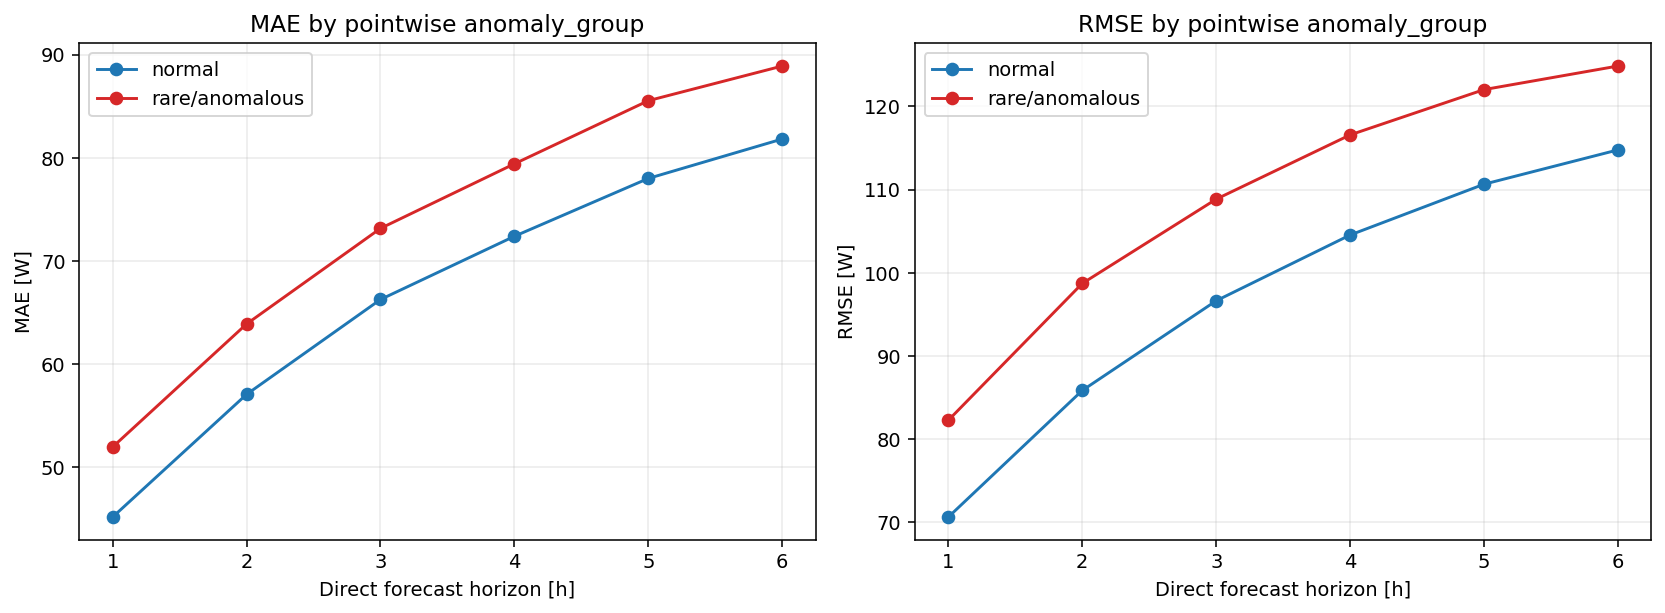

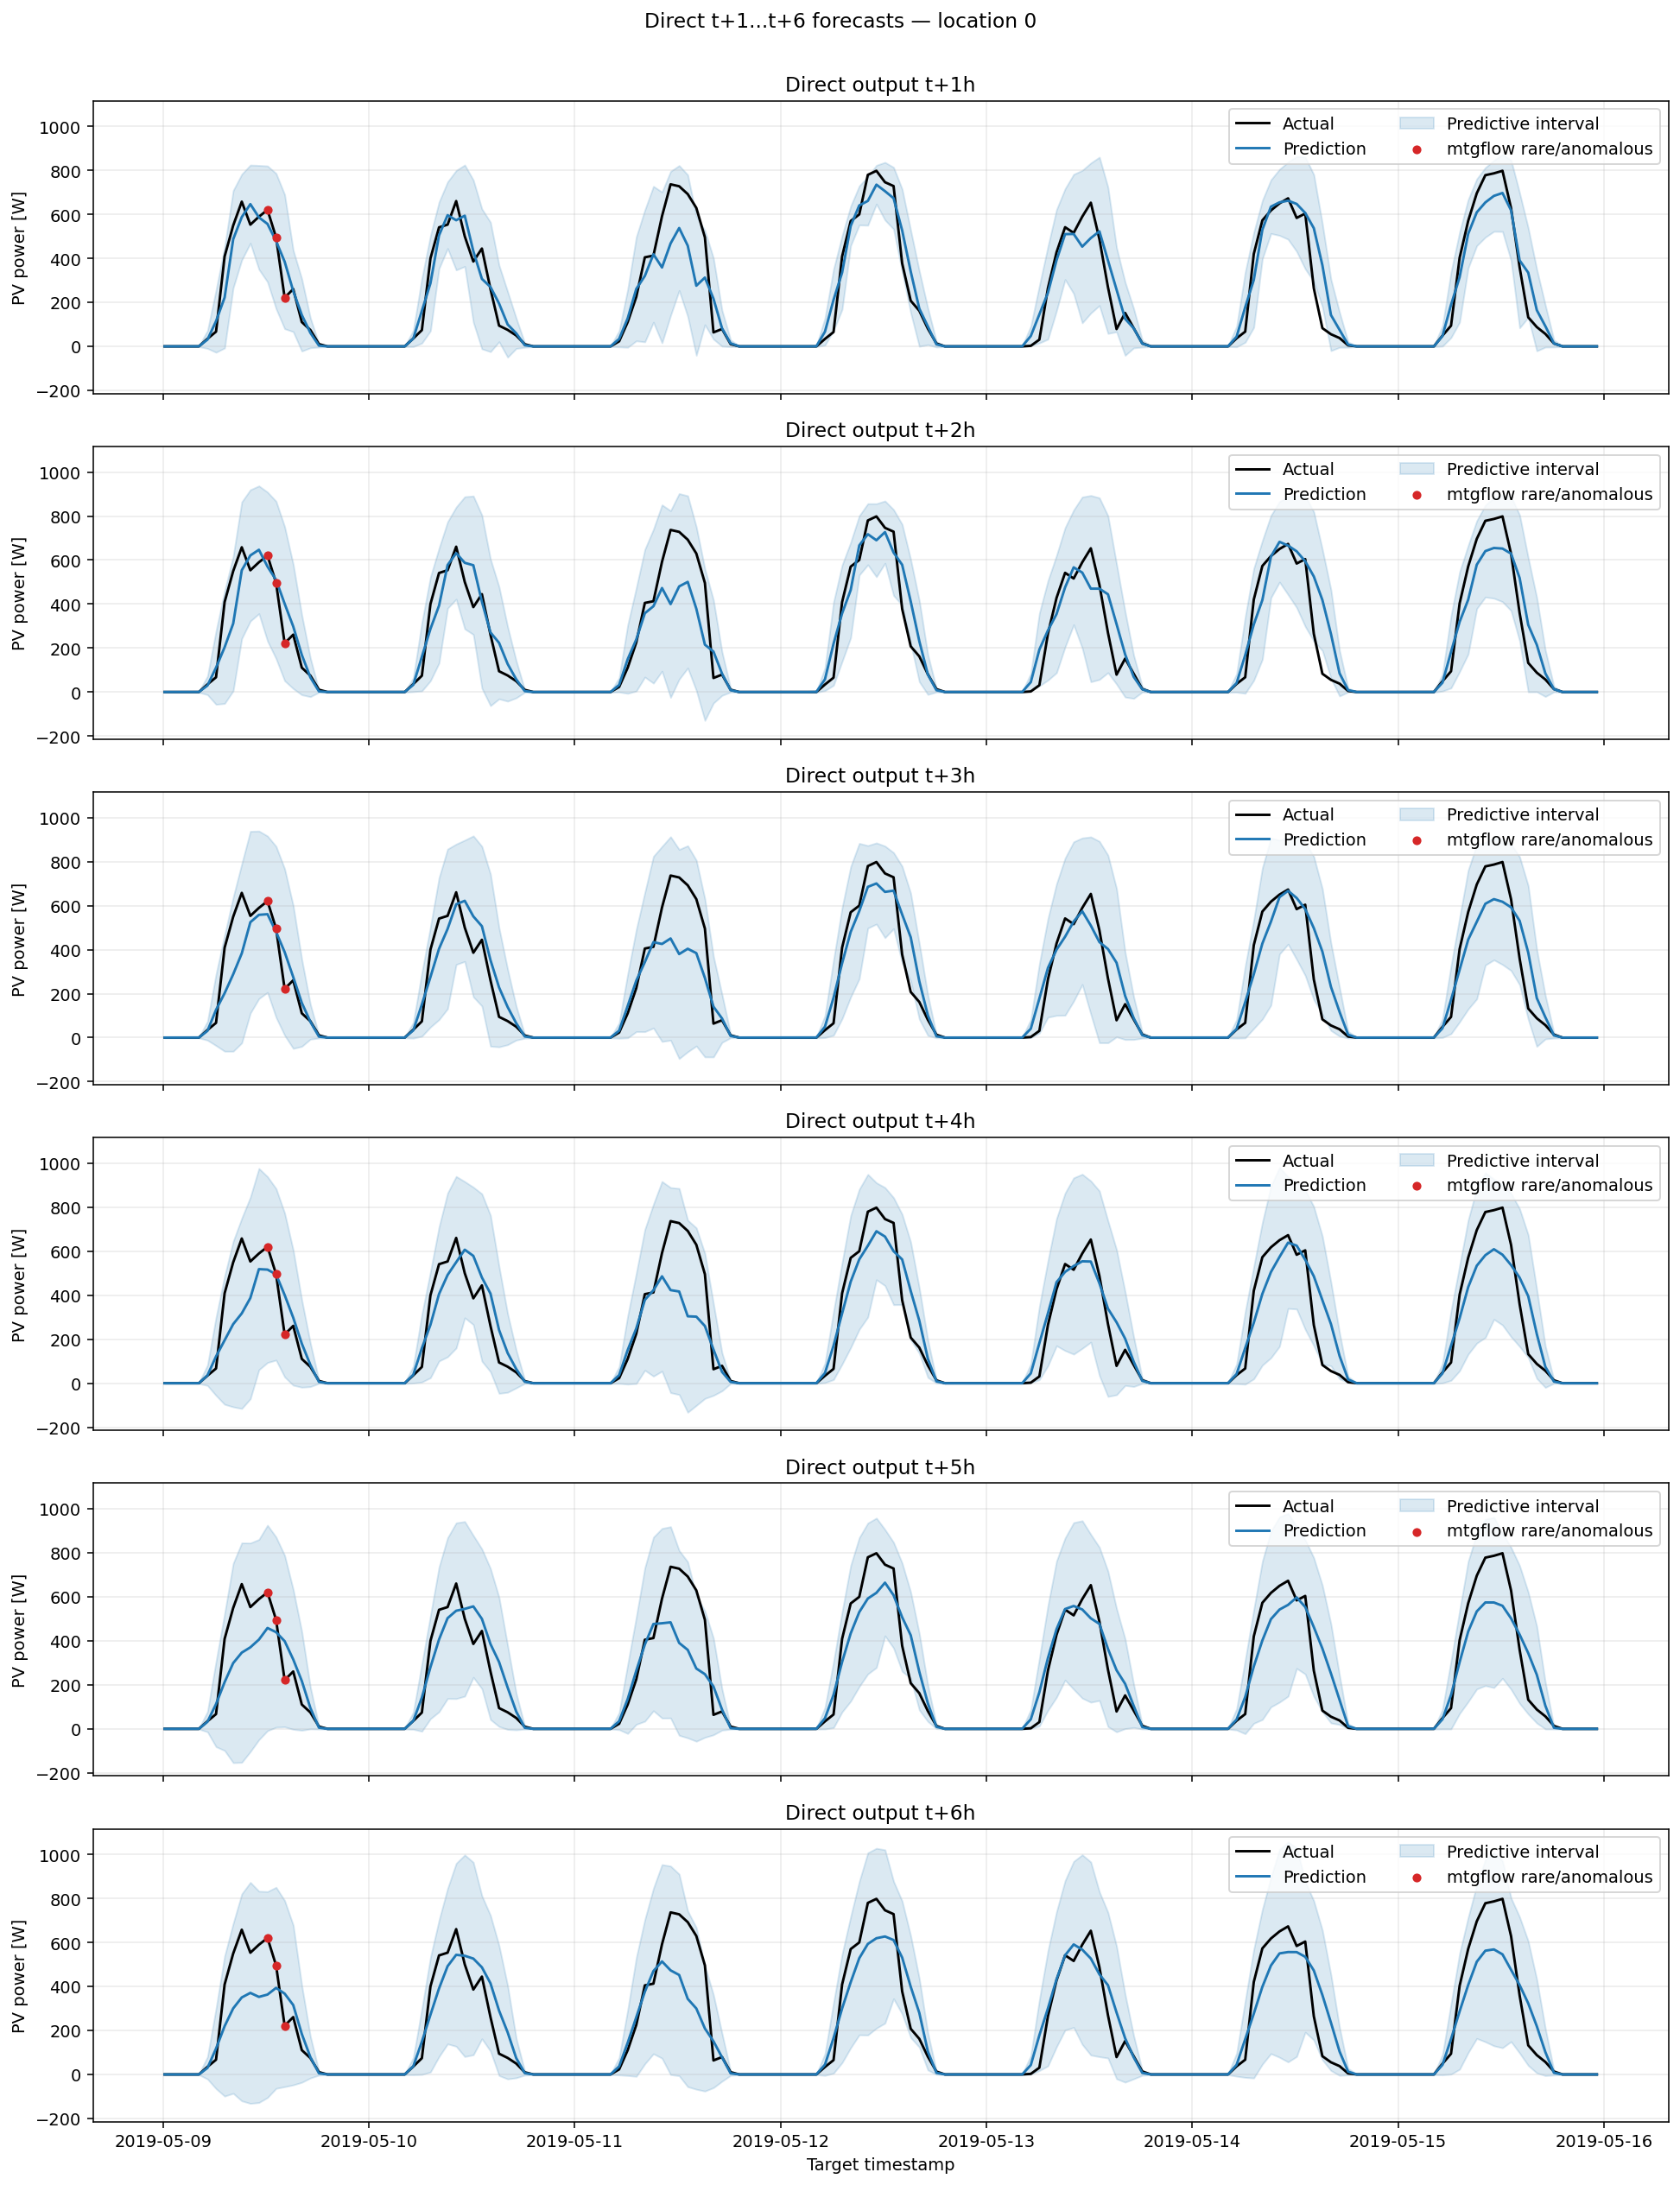

In [ ]:
from IPython.display import Image, Markdown, display
display(Image(filename=str(POSTHOC_PATHS['error_figure'])))
display(Image(filename=str(POSTHOC_PATHS['boxplot_figure'])))
display(Image(filename=str(POSTHOC_PATHS['histogram_figure'])))
display(Image(filename=str(POSTHOC_PATHS['prediction_figure'])))
for horizon, figures in FULL_POSTHOC_FIGURES.items():
    display(Markdown(f'## Suite paper-faithful t+{horizon}h'))
    for name, path in sorted(figures.items()):
        display(Markdown(f'**{name}**'))
        display(Image(filename=str(path)))